# LangChain vs LangGraph vs DeepAgent

In [1]:
from langchain.agents import create_agent
from langgraph.graph import StateGraph, START, END
from deepagents import create_deep_agent
from langchain_ollama.llms import OllamaLLM
from langchain_ollama import ChatOllama

__Key Insights__

This script compares agents from the three frameworks available within Langchain Ecosystem - langchain agent, langgraph agent/stateflow and deepagent.
Based on my research these are the senarios when each of them are recommende to use.
- **Langchain Agent** is recommended when task is simple such as ReAct type. The agent can be created using **create_agent** API and is capable enough to leverage tools passed under tool parameters. It does not require any explicit mention of the tool calling, making overall ReAct operations easily configurable. For complex or depth reasoning demanding tasks the agent may fail to meet expectation.

- **Langgraph Agent** does not exist on it's own. Instead, langgraph uses agents from Langchain as part of it's design. So, why should one use langgraph? For two major reasons, although there are many benefits associated using langgraph:

    - Langgraph helps to setup fixed flow multi-agent workflow, hence, making it still one of the best, frankly only, multi-agent orchestration framework. You can see below langframe provides high flexibility to design your own, reproducible flow of information, unlike langchain and deepagents.
    
    - Langgraph provides production deployable workflows, which is much desired when it comes to industry solution as a product.


- **Deep Agent** from langchain ecosystem, provides **create_deep_agent** API to create an agent and is similar to langchain **create_agent** with few key differences that make it overall powerful for complex tasks especially, involving deep reasoning. Deep Agents are very powerful capabilities for reasoning, planning and execution and highly recommended for any tasks that require "Chain of Thought" (CoT) or Tree of Throughts (ToT). The deepagents are powerful framework for Prototyping projects.

- **Lang Fuse** - LangFuse provides capabilities similar to deepagents with drop-and-drag features. It is also recommended for Prototyping projects.

__Create an Ollama LLM instance__

In [2]:
# llm = OllamaLLM(model="llama3.2:3b", temperature=0.1)

model = ChatOllama(model="llama3.2:3b", )

## LangChain Agent

In [3]:
def check_weather(location: str) -> str:
    '''Return the weather forecast for the specified location.'''
    return f"It's always sunny in {location}"

lc_agent = create_agent(
    model=model,
    tools=[check_weather],
    system_prompt="You are a helpful assistant",
)

In [4]:
inputs = {"messages": [{"role": "user", "content": "what is the weather in sf"}]}
for chunk in lc_agent.stream(inputs, stream_mode="updates"):
    if 'model' in chunk:
        print(chunk['model']['messages'][0].content)
    elif 'tools' in chunk:
        print(chunk['tools']['messages'][0].content)


It's always sunny in sf
I think there may be a bit of humor here! Unfortunately, San Francisco (SF) does not have perpetual sunshine. According to current weather conditions, the temperature is around 58°F (14°C) with partly cloudy skies.

Would you like me to check the current weather for a specific date or location?


__Workflow Diagram__

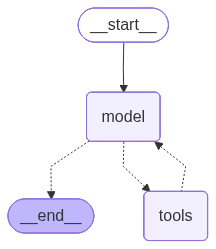

In [5]:
lc_agent

## LangGraph Agent 

In [6]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage
from typing import TypedDict

class State(TypedDict):
    question: str
    location: str
    answer: str

def location_agent(state: State) -> State:
    extractor = create_agent(
        model=model,
        system_prompt="You are an extractor. Identify the location in the user's query. "
                      "Output ONLY the location name as plain text."
    )
    messages = [
        SystemMessage(content="Extract the location mentioned in the user's query."),
        HumanMessage(content=state["question"])
    ]
    result = extractor.invoke({"messages": messages})
    state['location'] = result['messages'][2].content
    return {"question": state["question"], "location": state['location']}

def check_weather(state:State):
    """Return the weather forecast for the specified location."""
    location = state['location']
    state['answer'] = f"It's always sunny in {location}"
    return  {"format": "It's always sunny in location", "answer": state['answer']}

def response_agent(state: State) -> State:
    agent = create_agent(
        model=model,
        system_prompt="You are a helpful assistant. Respond naturally to the user input."
    )
    
    # Proper message objects
    messages = [
        SystemMessage(content="You are a helpful assistant."),
        HumanMessage(content=state["answer"])
    ]
    
    result = agent.invoke({"messages": messages})
    
    return {"question": state["question"], "answer": result['messages'][2].content}


In [7]:
builder = StateGraph(State)
builder.add_node('location_parser', location_agent)
builder.add_node('weather_tool', check_weather)
builder.add_node("response_generator", response_agent)
builder.add_edge(START, "location_parser")
builder.add_edge("location_parser", 'weather_tool')
builder.add_edge("weather_tool", 'response_generator')
builder.add_edge("response_generator", END)

app = builder.compile()

for step in app.stream({"question": "What is the weather of SF?"}):
    print(step)

{'location_parser': {'question': 'What is the weather of SF?', 'location': 'SF \n( San Francisco )'}}
{'weather_tool': {'answer': "It's always sunny in SF \n( San Francisco )"}}
{'response_generator': {'question': 'What is the weather of SF?', 'answer': 'San Francisco, also known as "The City by the Bay" or "Sunny Sf" (as you humorously put it!), indeed boasts an average of over 300 days of sunshine per year!\n\nWhile it\'s not uncommon for fog to roll in, especially during the summer months, San Francisco\'s proximity to the Pacific Ocean and its unique topography create a microclimate that often brings clear skies.\n\nThe city\'s sunny weather makes it an ideal destination for outdoor activities like hiking, biking, or simply enjoying the beautiful views of the Golden Gate Bridge and Alcatraz Island. \n\nHow can I help you explore San Francisco further?'}}


__WorkFlow Diagram__

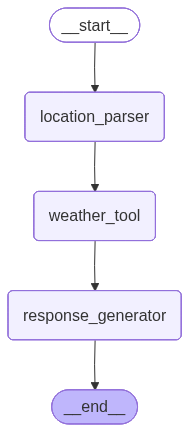

In [8]:
app

## Deep Agents

In [9]:
from langchain_core.tools import tool

@tool("check_weather", return_direct=True) ### Declaring the tool as a decorator is a MUST to work with deepagents
def check_weather(location: str) -> str:
    """Return the weather forecast for the specified location."""
    return f"It's always sunny in {location}"

deepagent = create_deep_agent(
    model=model,
    tools=[check_weather],
    system_prompt="You are a support bot. When asked about weather, always call the check_weather tool with the location extracted from the question.",

)
result = deepagent.invoke({"messages": [{"role": "user", "content": "what is temperatur in SF?"}]}, )

## Return
messages = result["messages"]
answer = messages[-1].content
print(answer)

Unfortunately, I don't have real-time access to current weather conditions or forecasts. However, I can suggest some ways for you to find out the current temperature in San Francisco (SF).

1. **Check online weather websites**: You can check websites like weather.com, accuweather.com, or wunderground.com for the current temperature in San Francisco.
2. **Use a virtual assistant**: You can ask virtual assistants like Siri, Google Assistant, or Alexa to tell you the current temperature in San Francisco.
3. **Check social media**: Many cities, including San Francisco, have official Twitter accounts that post updates on weather conditions. You can search for "@SFGov" or "@SanFrancisco" to see if they've posted any recent weather updates.
4. **Use a weather app**: If you have a smartphone, you can download a weather app like Dark Sky or Weather Underground to get the current temperature and forecast for San Francisco.

Please note that these options might not be available in all locations o

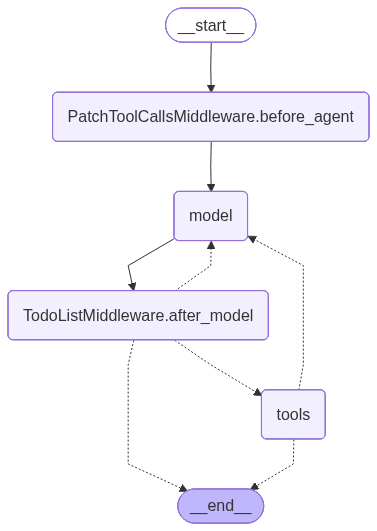

In [10]:
display(deepagent)

# 